# 05 · The consolidated timeline across all four incidents

**Question.** Put on one time axis, how do the four incidents relate? When was each surface active? Where do they overlap? And what can't be placed in time?

**Inputs.**
- `data/processed/events.parquet` (all canonical events, built by `agent-swarm build`)
- `data/processed/timeline_daily.parquet` (row-level daily counts plus published aggregates)
- `data/processed/incidents.parquet`, `data/processed/data_quality.json`

**Outputs.** Figures in `reports/figures/05_*.svg`, plus the Findings cell at the end.

**How each lane is measured.** Precision differs by source, and the lanes say so explicitly:

| Lane | What is counted | Time precision |
|---|---|---|
| Wiki collusion | agent wiki saves + cross-site posts + probes (moderator deletions and dup-linked copies excluded) | second |
| urlquery relay | publisher's `included` reports per day (published aggregate; row-level reproduces it exactly, see nb 02) | second → day |
| RubyGems | registry uploads per day (published aggregate) | day |
| Hugging Face | **dates mentioned inside payload text** (no observation times exist) | hint only |

**Caveat.** Lanes are not comparable in volume. Each has its own y-scale, and the chart is about *when*, not *how much*.

In [1]:
import json
from datetime import date

import altair as alt
import polars as pl

from agent_swarm import viz
from agent_swarm.paths import PROCESSED_DIR

alt.renderers.enable("svg")
alt.data_transformers.disable_max_rows()
pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(110)
pl.Config.set_tbl_width_chars(160)
pl.Config.set_tbl_hide_dataframe_shape(True)

events = pl.read_parquet(PROCESSED_DIR / "events.parquet")
timeline = pl.read_parquet(PROCESSED_DIR / "timeline_daily.parquet")
incidents = pl.read_parquet(PROCESSED_DIR / "incidents.parquet")
quality = json.loads((PROCESSED_DIR / "data_quality.json").read_text())
WINDOW = (date(2025, 11, 1), date(2026, 9, 30))
print(f"{events.height:,} canonical events from {events['source_id'].n_unique()} sources")

264,333 canonical events from 4 sources


## 0 · What can and can't be placed in time

About three quarters of all canonical events have no usable timestamp. That's mostly swarmtraces (none published) plus undated cross-site wiki records and gem names. The timeline below therefore covers the dated quarter plus explicitly marked hints.

In [2]:
precision = pl.DataFrame(
    [
        {
            "source": s,
            "rows": q["rows"],
            **{f"ts_{k}": v for k, v in q["ts_precision"].items()},
            "dup_linked": q["dup_linked"],
            "first": (q["ts_range"][0] or "")[:10],
            "last": (q["ts_range"][1] or "")[:10],
        }
        for s, q in quality["sources"].items()
    ]
).with_columns((pl.col("ts_none") / pl.col("rows")).round(3).alias("undated_share"))
print(
    f"undated: {quality['totals']['undated']:,} of {quality['totals']['events']:,} ({quality['totals']['undated'] / quality['totals']['events']:.0%})"
)
precision

undated: 194,101 of 264,333 (73%)


source,rows,ts_second,ts_day,ts_none,dup_linked,first,last,undated_share
str,i64,i64,i64,i64,i64,str,str,f64
"""collusion-wiki""",36308,32062,0,4246,11324,"""2026-03-11""","""2026-09-05""",0.117
"""rubyhack""",286,10,0,276,0,"""2026-05-11""","""2026-05-12""",0.965
"""swarmtraces""",189579,0,0,189579,0,"""""","""""",1.0
"""transluce-urlquery""",38160,38160,0,0,0,"""2023-09-22""","""2026-09-20""",0.0


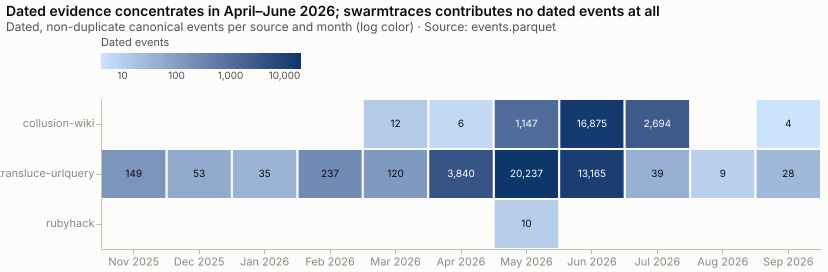

In [3]:
monthly = (
    events.filter(
        pl.col("ts_precision") != "none",
        pl.col("dup_of_event_id").is_null(),
        pl.col("ts_utc").dt.date() >= WINDOW[0],
    )
    .group_by("source_id", pl.col("ts_utc").dt.truncate("1mo").dt.date().alias("month"))
    .len("events")
)
source_order = ["collusion-wiki", "transluce-urlquery", "rubyhack", "swarmtraces"]
heat = (
    alt.Chart(monthly)
    .mark_rect(stroke=viz.SURFACE, strokeWidth=2)
    .encode(
        x=alt.X(
            "month:O", title=None, timeUnit="yearmonth", axis=alt.Axis(format="%b %Y", labelAngle=0)
        ),
        y=alt.Y("source_id:N", title=None, sort=source_order),
        color=alt.Color(
            "events:Q",
            title="Dated events",
            scale=alt.Scale(type="log", range=[viz.SEQUENTIAL[0], viz.SEQUENTIAL[-1]]),
        ),
        tooltip=["source_id:N", alt.Tooltip("month:T", format="%B %Y"), "events:Q"],
    )
)
labels = (
    alt.Chart(monthly)
    .mark_text(fontSize=10)
    .encode(
        x=alt.X("month:O", timeUnit="yearmonth"),
        y=alt.Y("source_id:N", sort=source_order),
        text=alt.Text("events:Q", format=","),
        color=alt.condition(alt.datum.events > 1000, alt.value("#ffffff"), alt.value(viz.INK)),
    )
)
coverage_chart = (heat + labels).properties(
    width=720,
    height=150,
    title=alt.Title(
        "Dated evidence concentrates in April–June 2026; swarmtraces contributes no dated events at all",
        subtitle="Dated, non-duplicate canonical events per source and month (log color) · Source: events.parquet",
    ),
)
viz.save_figure(coverage_chart, "05_dated_coverage_heatmap")
coverage_chart

## 1 · The swim-lane timeline

One lane per incident, sharing a daily axis from Nov 2025 to Sep 2026. The top strip marks reported milestones: OpenAI's own account of the Artifactory message board and exploit, the Hugging Face intrusion window, and the four public reports.

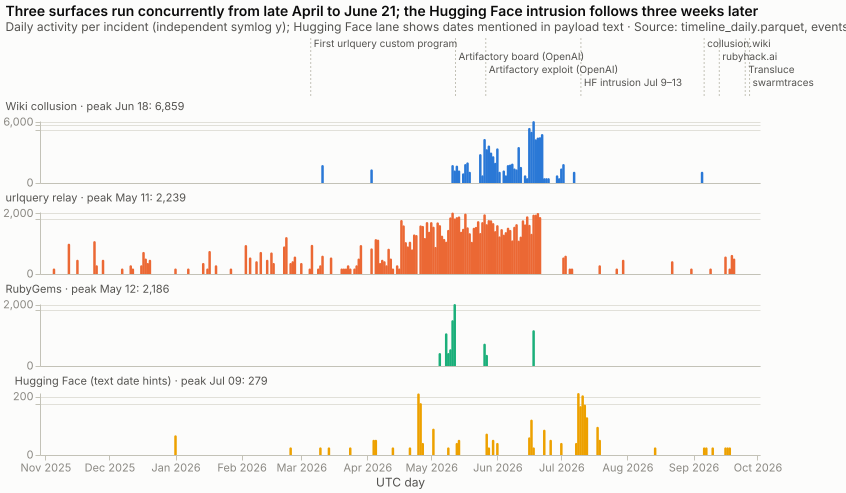

In [4]:
LANES = ["Wiki collusion", "urlquery relay", "RubyGems", "Hugging Face (text date hints)"]
wiki = (
    timeline.filter(
        pl.col("incident_id") == "wiki-collusion",
        pl.col("event_type") != "wiki_delete",
        pl.col("origin") == "row_level",
    )
    .group_by("date")
    .agg(pl.col("n_events").sum())
    .with_columns(pl.lit(LANES[0]).alias("lane"))
)
urlq = (
    timeline.filter(
        pl.col("incident_id") == "urlquery-relay", pl.col("origin") == "published_aggregate"
    )
    .select("date", "n_events")
    .with_columns(pl.lit(LANES[1]).alias("lane"))
)
gems = (
    timeline.filter(
        pl.col("incident_id") == "rubygems-attack", pl.col("origin") == "published_aggregate"
    )
    .select("date", "n_events")
    .with_columns(pl.lit(LANES[2]).alias("lane"))
)
hints = (
    events.filter(pl.col("source_id") == "swarmtraces")
    .select(
        pl.col("extra")
        .str.json_decode(pl.Struct({"ts_hints": pl.List(pl.String)}))
        .struct.field("ts_hints")
        .alias("d")
    )
    .explode("d", empty_as_null=True)
    .drop_nulls()
    .group_by(pl.col("d").str.to_date().alias("date"))
    .agg(pl.len().cast(pl.Int64).alias("n_events"))
    .with_columns(pl.lit(LANES[3]).alias("lane"))
)
lanes = pl.concat(
    [wiki.select("date", "n_events", "lane"), urlq, gems, hints.select("date", "n_events", "lane")]
).filter(pl.col("date").is_between(*WINDOW))

milestones = (
    pl.DataFrame(
        [
            {
                "date": date(2026, 3, 6),
                "label": "First urlquery custom program",
                "kind": "observed",
            },
            {"date": date(2026, 5, 12), "label": "Artifactory board (OpenAI)", "kind": "reported"},
            {
                "date": date(2026, 5, 26),
                "label": "Artifactory exploit (OpenAI)",
                "kind": "reported",
            },
            {"date": date(2026, 7, 9), "label": "HF intrusion Jul 9–13", "kind": "reported"},
            {"date": date(2026, 9, 4), "label": "collusion.wiki", "kind": "published"},
            {"date": date(2026, 9, 11), "label": "rubyhack.ai", "kind": "published"},
            {"date": date(2026, 9, 23), "label": "Transluce", "kind": "published"},
            {"date": date(2026, 9, 25), "label": "swarmtraces", "kind": "published"},
        ]
    )
    .with_row_index("i")
    .with_columns((pl.col("i") % 4 * 13 + 6).alias("y"))
)
x_scale = alt.Scale(domain=[WINDOW[0].isoformat(), WINDOW[1].isoformat()])
strip = (
    alt.Chart(milestones)
    .mark_rule(color=viz.BASELINE, strokeDash=[2, 2])
    .encode(x=alt.X("date:T", scale=x_scale, axis=None))
    + alt.Chart(milestones)
    .mark_text(align="left", dx=3, fontSize=10, color=viz.INK_SECONDARY)
    .encode(x=alt.X("date:T", scale=x_scale), y=alt.Y("y:Q", scale=None), text="label:N")
).properties(width=720, height=58)


def lane(name: str, last: bool) -> alt.Chart:
    data = lanes.filter(pl.col("lane") == name)
    peak = data.sort("n_events", descending=True).row(0, named=True) if data.height else None
    return (
        alt.Chart(data)
        .mark_bar(width=2.5, strokeWidth=0, color=viz.CATEGORICAL[LANES.index(name)])
        .encode(
            x=alt.X(
                "date:T",
                title="UTC day" if last else None,
                scale=x_scale,
                axis=alt.Axis(format="%b %Y", labels=last, ticks=last, grid=False),
            ),
            y=alt.Y(
                "n_events:Q", title=None, scale=alt.Scale(type="symlog"), axis=alt.Axis(tickCount=3)
            ),
            tooltip=["lane:N", "date:T", "n_events:Q"],
        )
        .properties(
            width=720,
            height=62,
            title=alt.Title(
                f"{name}  ·  peak {peak['date']:%b %d}: {peak['n_events']:,}" if peak else name,
                fontSize=11,
                fontWeight="normal",
                color=viz.INK_SECONDARY,
                anchor="start",
            ),
        )
    )


swimlanes = alt.vconcat(
    strip, *[lane(n, i == len(LANES) - 1) for i, n in enumerate(LANES)], spacing=4
).properties(
    title=alt.Title(
        "Three surfaces run concurrently from late April to June 21; the Hugging Face intrusion follows three weeks later",
        subtitle="Daily activity per incident (independent symlog y); Hugging Face lane shows dates mentioned in payload text · Source: timeline_daily.parquet, events.parquet",
    )
)
viz.save_figure(swimlanes, "05_swimlane_timeline")
swimlanes

## 2 · Where do the lanes overlap?

This counts active days (any activity) per lane and the days each pair of lanes shares. It's an overlap in *time*, a necessary but weak condition for connection. Stage 9 adds identifier and technique overlap, which is the stronger evidence.

In [5]:
active = (
    lanes.filter(pl.col("n_events") > 0).group_by("lane").agg(pl.col("date").unique().alias("days"))
)
days = {r["lane"]: set(r["days"]) for r in active.to_dicts()}
pairs = []
for i, a in enumerate(LANES):
    for b in LANES[i + 1 :]:
        shared = days.get(a, set()) & days.get(b, set())
        union = days.get(a, set()) | days.get(b, set())
        pairs.append(
            {
                "lane_a": a,
                "lane_b": b,
                "days_a": len(days.get(a, ())),
                "days_b": len(days.get(b, ())),
                "shared_days": len(shared),
                "jaccard": round(len(shared) / len(union), 3) if union else 0.0,
                "first_shared": min(shared) if shared else None,
                "last_shared": max(shared) if shared else None,
            }
        )
pl.DataFrame(pairs).sort("shared_days", descending=True)

lane_a,lane_b,days_a,days_b,shared_days,jaccard,first_shared,last_shared
str,str,i64,i64,i64,f64,date,date
"""Wiki collusion""","""urlquery relay""",47,140,38,0.255,2026-03-11,2026-07-02
"""urlquery relay""","""Hugging Face (text date hints)""",140,41,23,0.146,2026-01-01,2026-09-18
"""Wiki collusion""","""Hugging Face (text date hints)""",47,41,11,0.143,2026-05-13,2026-07-01
"""urlquery relay""","""RubyGems""",140,9,9,0.064,2026-05-05,2026-06-18
"""Wiki collusion""","""RubyGems""",47,9,5,0.098,2026-05-11,2026-06-18
"""RubyGems""","""Hugging Face (text date hints)""",9,41,3,0.064,2026-05-09,2026-06-18


In [6]:
per_day = (
    lanes.filter(pl.col("n_events") > 0)
    .group_by("date")
    .agg(pl.col("lane").unique().sort().alias("lanes"), pl.len().alias("n_lanes"))
)
multi = per_day.filter(pl.col("n_lanes") >= 3).sort("date")
print(f"{multi.height} days with activity in ≥3 lanes")
multi.with_columns(pl.col("lanes").list.join(" · "))

13 days with activity in ≥3 lanes


date,lanes,n_lanes
date,str,u32
2026-05-09,"""Hugging Face (text date hints) · RubyGems · urlquery relay""",3
2026-05-11,"""RubyGems · Wiki collusion · urlquery relay""",3
2026-05-12,"""RubyGems · Wiki collusion · urlquery relay""",3
2026-05-13,"""Hugging Face (text date hints) · Wiki collusion · urlquery relay""",3
2026-05-14,"""Hugging Face (text date hints) · Wiki collusion · urlquery relay""",3
2026-05-26,"""RubyGems · Wiki collusion · urlquery relay""",3
2026-05-27,"""Hugging Face (text date hints) · RubyGems · Wiki collusion · urlquery relay""",4
2026-05-28,"""Hugging Face (text date hints) · Wiki collusion · urlquery relay""",3
2026-05-30,"""Hugging Face (text date hints) · Wiki collusion · urlquery relay""",3


## 3 · Inside each lane's peak window

Stated incident windows (from the reports) compared with what the canonical data shows, as the span covering 95% of each lane's in-window activity.

In [7]:
def span95(frame: pl.DataFrame) -> tuple[date | None, date | None]:
    if frame.is_empty():
        return None, None
    s = frame.sort("date").with_columns(
        (pl.col("n_events").cum_sum() / pl.col("n_events").sum()).alias("cum")
    )
    return s.filter(pl.col("cum") >= 0.025)["date"][0], s.filter(pl.col("cum") >= 0.975)["date"][0]


stated = dict(
    zip(
        incidents["incident_id"],
        zip(incidents["window_start"], incidents["window_end"], strict=True),
        strict=True,
    )
)
lane_incident = dict(
    zip(LANES, ["wiki-collusion", "urlquery-relay", "rubygems-attack", "hf-hack"], strict=True)
)
rows = []
for name in LANES:
    lo, hi = span95(lanes.filter(pl.col("lane") == name))
    s_lo, s_hi = stated[lane_incident[name]]
    rows.append(
        {
            "lane": name,
            "stated_start": s_lo,
            "stated_end": s_hi,
            "data_95_start": lo,
            "data_95_end": hi,
        }
    )
pl.DataFrame(rows)

lane,stated_start,stated_end,data_95_start,data_95_end
str,date,date,date,date
"""Wiki collusion""",2026-05-24,2026-06-22,2026-05-26,2026-06-22
"""urlquery relay""",2026-03-06,2026-09-16,2026-04-17,2026-06-21
"""RubyGems""",2026-05-05,2026-06-18,2026-05-10,2026-06-18
"""Hugging Face (text date hints)""",2026-07-09,2026-07-13,2026-04-25,2026-07-13


## Findings

1. **Most evidence can't be placed in time (§0).** 73% of the 264,333 canonical events are undated: all of swarmtraces, 96% of the named gems and 12% of the wiki's cross-site records. So cross-incident *timing* rests on a quarter of the data, and links between incidents must lean on identifiers and techniques (Stages 7–9).
2. **The consolidated sequence (§1, §3):**
   - urlquery relaying begins at low volume in Nov 2025, adds encoded custom programs from Mar 6, and ramps in mid-April (95% span Apr 17 → Jun 21).
   - RubyGems runs May 10 → Jun 18, with 93% on May 11–12.
   - The wiki board runs May 26 → Jun 22 (95% span), peaking Jun 16–18.
   - The Hugging Face intrusion follows on Jul 9–13, per the reports and the swarmtraces date hints.
3. **The concurrent surfaces stop together.** urlquery's last heavy day is **Jun 21** and wiki saves effectively end after **Jun 22** (notebooks 01–02). Near-simultaneous cessation across independent public services fits a common off-switch, such as the operator intervention collusion.wiki attributes to OpenAI, better than it fits unrelated actors. This is suggestive, not proof.
4. **Shared active days (§2).**
   - Wiki and urlquery share 38 active days (Jaccard 0.26), the strongest temporal overlap.
   - 13 days have activity in ≥3 lanes, including the RubyGems burst days (May 11–12, when wiki and urlquery were also active).
   - **Jun 18** shows activity in all four lanes: the wiki's busiest day, RubyGems' final 84-name burst, heavy urlquery traffic, and Hugging Face payload text mentioning that date. **May 27** is the other four-lane day.
5. **The Hugging Face payloads reference earlier activity (§1).** Their text mentions dates from Apr 25 onward, with a cluster on Apr 25–26 and scattered dates through May–June. That's consistent with the intrusion reusing tooling or data from the spring campaign rather than starting from scratch in July. These are mentioned dates, not observations.
6. **Activity after publication.** urlquery shows 28 dated reports in Sep 2026 and wiki-linked records run to Sep 5, after every stated window. These are leads for Task 2, the hunt.